# 🧠 Student Mental Health EDA

## Dataset
ข้อมูลจากการสำรวจนักศึกษามหาวิทยาลัย ครอบคลุมข้อมูลด้านสุขภาพจิต การเรียน และพฤติกรรมการนอนหลับ

| Column | Description |
|--------|-------------|
| Depression / Anxiety / PanicAttack | มีอาการหรือไม่ (0/1) |
| StudyStressLevel | ระดับความเครียด (1-5) |
| CGPA | เกรดเฉลี่ย |
| SleepQuality | คุณภาพการนอน (1-5) |
| StudyHoursPerWeek | ชั่วโมงเรียนต่อสัปดาห์ |

## วัตถุประสงค์
1. วิเคราะห์ว่านักศึกษากี่เปอร์เซ็นต์มีปัญหาสุขภาพจิต
2. หาความสัมพันธ์ระหว่าง stress, การนอน, เกรด และสุขภาพจิต
3. เปรียบเทียบตามสาขาวิชา เพศ และชั้นปี

อ้างอิง
[kaggle](https://www.kaggle.com/datasets/junnn0126/university-students-mental-health)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import numpy as np

In [2]:
df = pd.read_csv('mentalhealth_dataset_clean.csv')
data = df.copy()

In [3]:
# Data Quality Check
print('Shape:', data.shape)
print('\nMissing values:')
print(data.isnull().sum())

Shape: (1000, 16)

Missing values:
Timestamp                     0
Gender                        0
Age                           0
Course                        0
YearOfStudy                   0
CGPA                          0
Depression                    0
Anxiety                       0
PanicAttack                   0
SpecialistTreatment           0
SymptomFrequency_Last7Days    0
HasMentalHealthSupport        0
SleepQuality                  0
StudyStressLevel              0
StudyHoursPerWeek             0
AcademicEngagement            0
dtype: int64


In [4]:
data.sample(10)

,Timestamp,Gender,Age,Course,YearOfStudy,CGPA,Depression,Anxiety,PanicAttack,SpecialistTreatment,SymptomFrequency_Last7Days,HasMentalHealthSupport,SleepQuality,StudyStressLevel,StudyHoursPerWeek,AcademicEngagement
589,08/07/2022,Male,20,IRKHS,year 1,3.1,0,1,0,0,2,0,4,2,8,5
802,13/07/2023,Female,24,BCS,year 1,2.5,0,0,0,0,6,0,5,5,8,4
262,13/07/2021,Female,19,ENGINEERING,year 4,2.4,0,0,1,0,4,0,1,3,7,3
741,09/07/2022,Male,20,BIT,year 3,2.0,0,0,1,0,0,0,2,1,1,5
412,08/07/2021,Female,22,USULUDDIN,year 2,4.0,1,0,0,0,2,0,1,5,15,5
900,08/07/2023,Female,21,ENGINEERING,year 2,2.5,0,0,0,1,7,1,2,1,8,5
261,13/07/2021,Female,21,ENGINEERING,year 4,2.7,0,1,1,0,1,0,5,1,7,4
764,13/07/2023,Female,18,ENGINEERING,year 1,2.0,0,1,0,0,6,0,3,5,5,1
74,08/07/2020,Male,24,ENGINEERING,year 2,2.4,0,1,0,0,2,0,2,3,5,4
473,08/07/2021,Female,25,ENGIN,year 1,2.0,1,1,0,0,7,0,4,4,1,4


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   str    
 1   Gender                      1000 non-null   str    
 2   Age                         1000 non-null   int64  
 3   Course                      1000 non-null   str    
 4   YearOfStudy                 1000 non-null   str    
 5   CGPA                        1000 non-null   float64
 6   Depression                  1000 non-null   int64  
 7   Anxiety                     1000 non-null   int64  
 8   PanicAttack                 1000 non-null   int64  
 9   SpecialistTreatment         1000 non-null   int64  
 10  SymptomFrequency_Last7Days  1000 non-null   int64  
 11  HasMentalHealthSupport      1000 non-null   int64  
 12  SleepQuality                1000 non-null   int64  
 13  StudyStressLevel            1000 non-null   i

In [6]:
data['Depression']

0      1
1      0
2      0
3      0
4      1
      ..
995    0
996    1
997    0
998    1
999    1
Name: Depression, Length: 1000, dtype: int64

In [7]:
data['Course'] = data['Course'].str.lower()

In [8]:
corrections = {
    'benl': 'Bachelor of English Language and Literature',
    'koe': 'Kulliyyah of Engineering',
    'psychology': 'Bachelor of Human Sciences in Psychology',
    'fiqh': 'Bachelor of Islamic Revealed Knowledge and Heritage',
    'fiqh fatwa': 'Bachelor of Islamic Revealed Knowledge and Heritage',
    'engin': 'Kulliyyah of Engineering',
    'engine': 'Kulliyyah of Engineering',
    'engineering': 'Kulliyyah of Engineering',
    'mathemathics': 'Bachelor of Mathematical Sciences',
    'law': 'Bachelor of Laws',
    'laws': 'Bachelor of Laws',
    'pendidikan islam': 'Bachelor of Education (Islamic Education)',
    'it': 'Bachelor of Information Technology (BIT)',
    'accounting': 'Bachelor of Accounting (BAcc)',
    'ala': 'Bachelor of Arabic Language and Literature (ALA)',
    'banking studies': 'Kulliyyah of Economics and Management Sciences',
    'bcs': 'Bachelor of Computer Science (BCS)',
    'biomedical science': 'Bachelor of Biomedical Science',
    'biotechnology': 'Bachelor of Biotechnology',
    'business administration': 'Bachelor of Business Administration (BBA)',
    'bit': 'Bachelor of Information Technology (BIT)',
    'communication': 'Bachelor of Human Sciences in Communication',
    'cts': 'Bachelor of Science (BSc) in Computational and Theoretical Sciences',
    'diploma nursing': 'Bachelor of Nursing',
    'diploma tesl': 'Bachelor of Education in Teaching English as a Second Language (TESL)',
    'econs': 'Bachelor of Economics',
    'enm': 'Bachelor of Economics',
    'human resources': 'Kulliyyah of Economics and Management Sciences',
    'human sciences': 'Bachelor of Human Sciences',
    'irkhs': 'Kulliyyah of Islamic Revealed Knowledge and Human Sciences',
    'islamic education': 'Bachelor of Islamic Education',
    'kenms': 'Kulliyyah of Economics and Management Sciences (KENMS)',
    'kop': 'Kulliyyah of Pharmacy (KOP)',
    'malcom': 'Bachelor of Arts in Malay for International Communication ',
    'marine science': 'Bachelor of Marine Science',
    'mhsc': 'Master of Health Science',
    'nursing': 'Bachelor of Nursing',
    'radiography': 'Bachelor of Radiography and Diagnostic Imaging',
    'taasl': 'Teaching Arabic as a Second Language',
    'usuluddin': 'Bachelor of Usuluddin',
    'kirkhs': 'Kulliyyah of Islamic Revealed Knowledge and Human Sciences',
}
data['Course'] = data['Course'].replace(corrections)

In [9]:
# รวม Depression, Anxiety, PanicAttack เป็น column เดียวเพื่อง่ายต่อการวิเคราะห์
# สร้าง column "Mental Health Issues" โดยใช้ Depression, Anxiety, PanicAttack
data.loc[(data["Depression"]==1) | (data["Anxiety"]==1) | (data["PanicAttack"]==1),'Mental Health Issues']= 'Yes'
data.loc[(data["Depression"]==0) & (data["Anxiety"]==0) & (data["PanicAttack"]==0),'Mental Health Issues']= 'No'


# แบ่ง dataframe เป็น 2 กลุ่ม มีและไม่มีปัญหาสุขภาพจิต
mental_health_yes = data[data["Mental Health Issues"] == 'Yes']
mental_health_no = data[data["Mental Health Issues"] == 'No']

data["Mental Health Issues"].value_counts()

Mental Health Issues
Yes    845
No     155
Name: count, dtype: int64

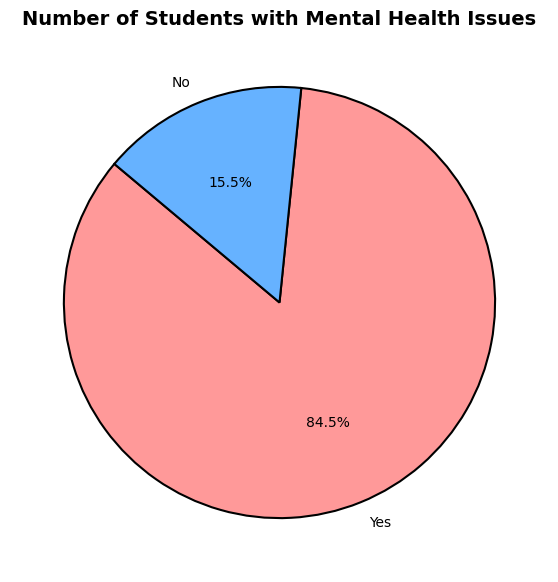

In [10]:
colors = ["#FF9999", "#66B2FF"]

plt.figure(figsize=(7, 7))  
plt.pie(data['Mental Health Issues'].value_counts(),
        labels=['Yes', 'No'],
        autopct='%.1f%%',          startangle=140,          colors=colors,  
        wedgeprops={"edgecolor": "black", "linewidth": 1.5})

# ตั้งชื่อกราฟ
plt.title('Number of Students with Mental Health Issues', fontsize=14, fontweight='bold')

# แสดงผล
plt.show()

## 🔍 Insight
นักศึกษาส่วนใหญ่ **มีปัญหาสุขภาพจิต** (Depression, Anxiety หรือ PanicAttack อย่างน้อย 1 อย่าง) ซึ่งบ่งชี้ว่าปัญหานี้เป็นเรื่องที่พบได้ทั่วไปในกลุ่มนักศึกษา

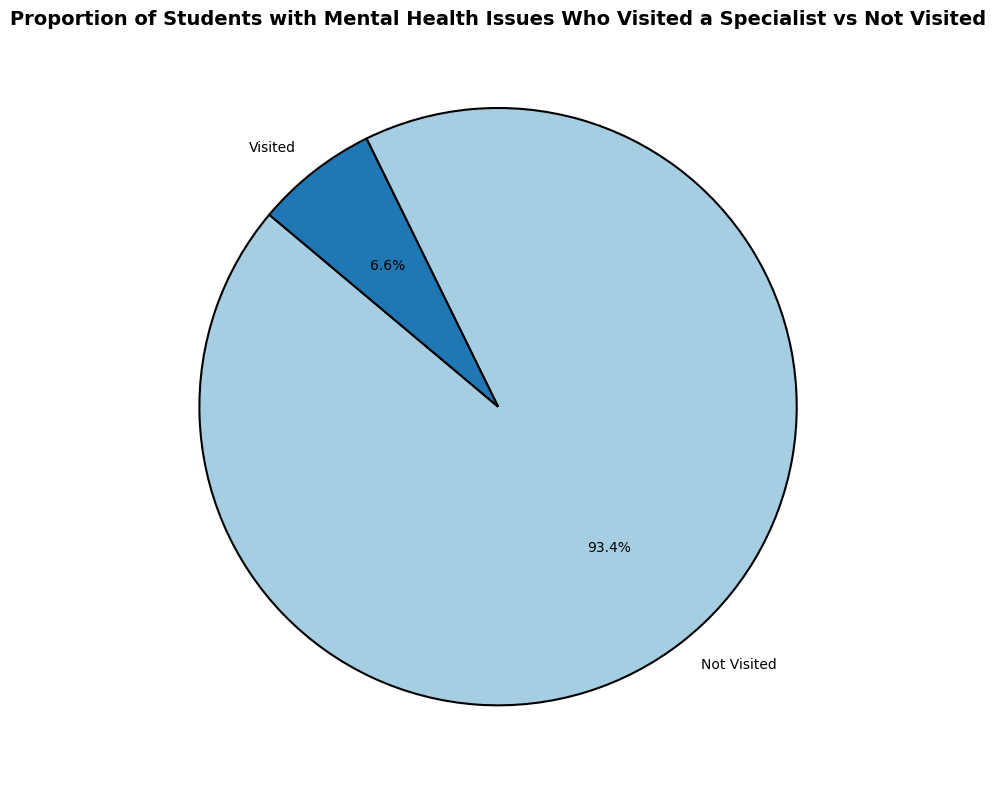

In [ ]:
# กรองเฉพาะ stress level 5 เพื่อวิเคราะห์กรณีที่รุนแรงที่สุด
# สร้าง column แยกว่าพบผู้เชี่ยวชาญหรือไม่ จาก SpecialistTreatment
data['Visited Specialist'] = data.apply(lambda row: 'Visited' if row['SpecialistTreatment'] == 1 else 'Not Visited', axis=1)

mental_health_specialist_data = data[data['Mental Health Issues'] == 'Yes']

specialist_visit_count = mental_health_specialist_data['Visited Specialist'].value_counts()

# วาด Pie chart
plt.figure(figsize=(8, 8))
plt.pie(specialist_visit_count,
        labels=specialist_visit_count.index,
        autopct='%.1f%%', 
        startangle=140,  
        colors=plt.cm.Paired.colors, 
        wedgeprops={"edgecolor": "black", "linewidth": 1.5}) 


plt.title('Proportion of Students with Mental Health Issues Who Visited a Specialist vs Not Visited', fontsize=14, fontweight='bold')

# แสดงผล
plt.tight_layout()
plt.show()

In [ ]:
mental_health_no_course = mental_health_no.groupby("Course")["Mental Health Issues"].count()
mental_health_yes_course = mental_health_yes.groupby("Course")["Mental Health Issues"].count()

mental_health_no_course = mental_health_no_course.sort_values(ascending = False)
mental_health_yes_course = mental_health_yes_course.sort_values(ascending = False)

new_df = pd.concat([mental_health_yes_course, mental_health_no_course], axis=1)

# เปลี่ยนชื่อ column
new_df.columns.values[0] = "Has Mental Health Issues"
new_df.columns.values[1] = "No Mental Health Issues"

new_df.fillna(0, inplace = True)
new_df['Total'] = new_df['Has Mental Health Issues'] + new_df['No Mental Health Issues']

# เรียงลำดับ
new_df = new_df.sort_values(by=['Total','Has Mental Health Issues', 'No Mental Health Issues'], ascending=False)

new_df = new_df.reset_index(level=0)

new_df.head()

# เลือกเฉพาะคอร์สที่ได้รับความนิยมสูงสุด (เช่น Top 10)
top_courses = new_df.head(10)
top_courses

,Course,Has Mental Health Issues,No Mental Health Issues,Total
0,Kulliyyah of Engineering,235,39.0,274.0
1,Bachelor of Computer Science (BCS),143,34.0,177.0
2,Bachelor of Information Technology (BIT),92,17.0,109.0
3,Bachelor of Biomedical Science,26,7.0,33.0
4,Kulliyyah of Islamic Revealed Knowledge and Hu...,28,4.0,32.0
5,Bachelor of Laws,27,5.0,32.0
6,Bachelor of Human Sciences in Psychology,26,3.0,29.0
7,Bachelor of Education (Islamic Education),25,4.0,29.0
8,Bachelor of English Language and Literature,17,7.0,24.0
9,Bachelor of Nursing,17,4.0,21.0


Text(0.5, 1.0, 'Count of Students with MH Issues')

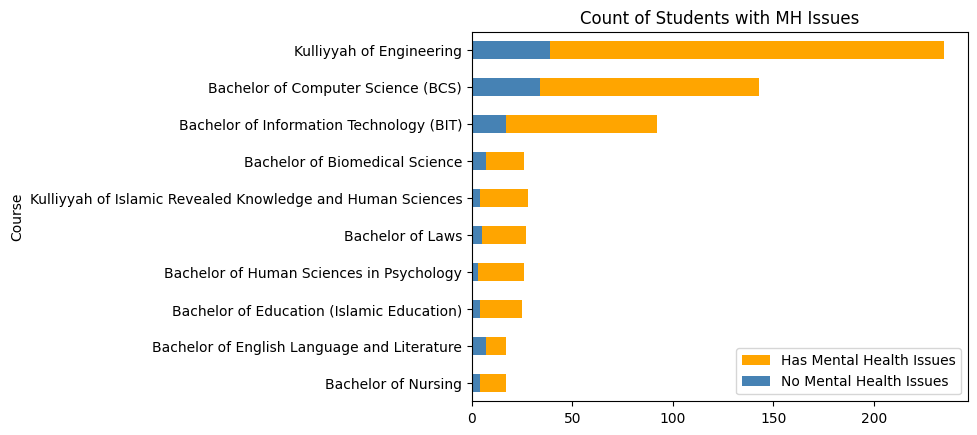

In [13]:
top_courses = top_courses.sort_values(by=['Total','Has Mental Health Issues', 'No Mental Health Issues'], ascending=True)

ax = top_courses.plot(x="Course", y="Has Mental Health Issues", kind="barh", color = 'orange')

top_courses.plot(x="Course", y="No Mental Health Issues", kind="barh", ax=ax, color = 'steelblue')
plt.title('Count of Students with MH Issues')

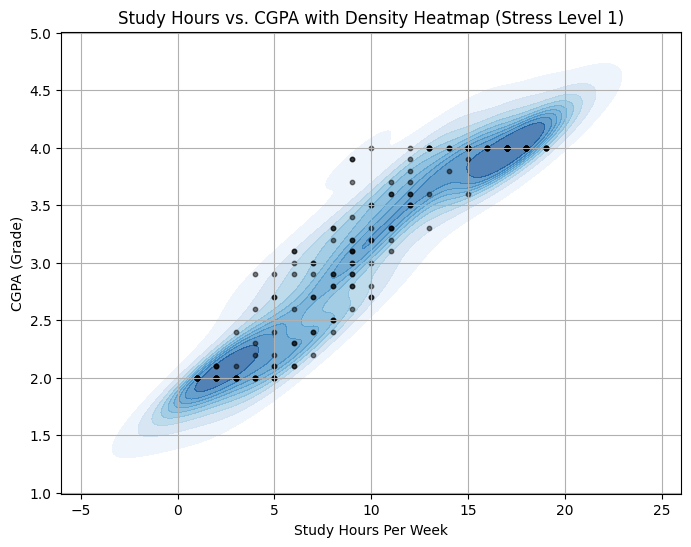

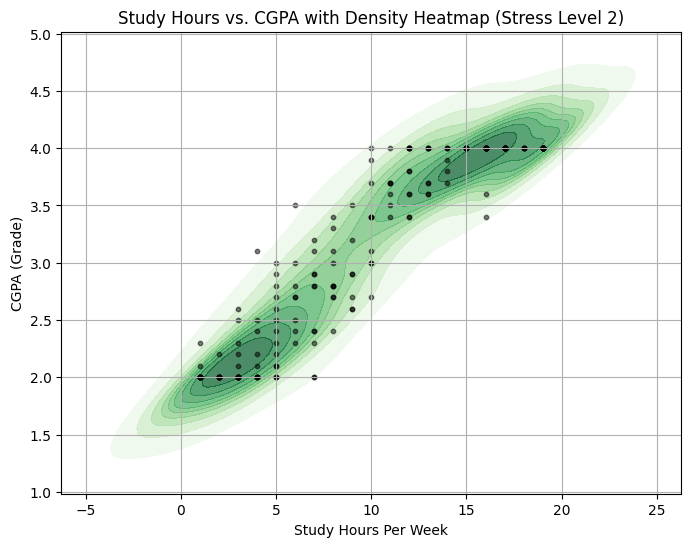

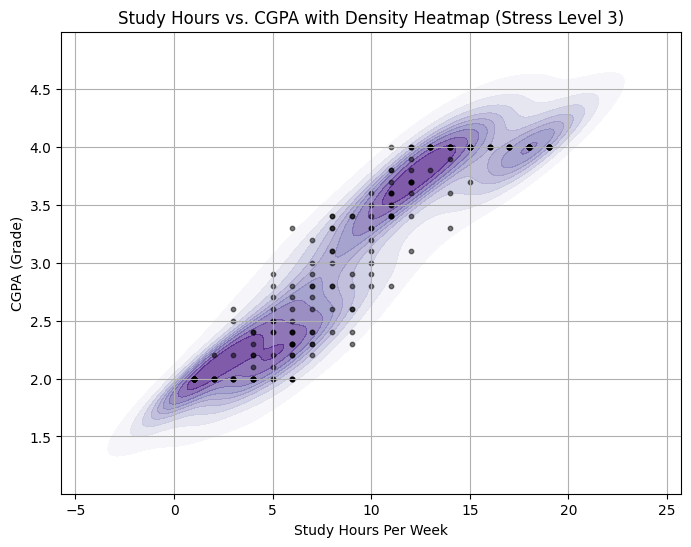

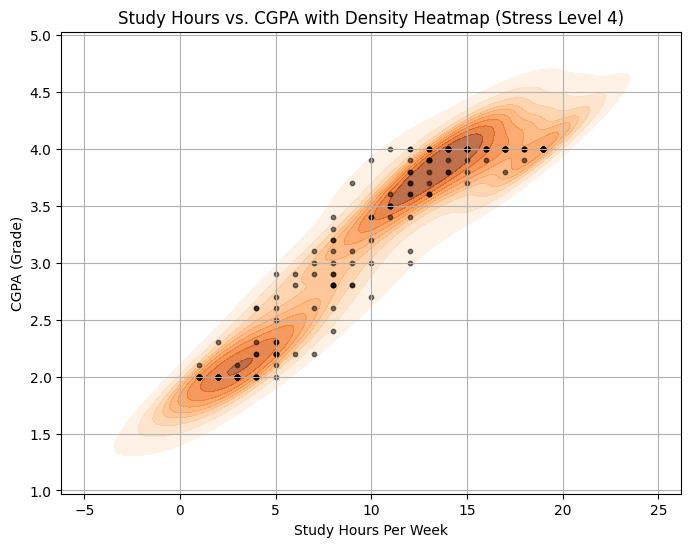

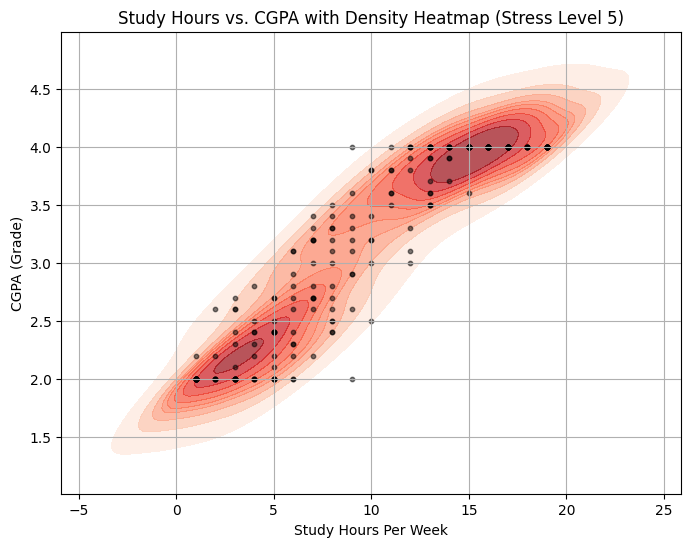

In [14]:

# กำหนด stress level ที่จะ plot (1-5)
stress_levels = [1, 2, 3, 4, 5]
colors = ['Blues', 'Greens', 'Purples', 'Oranges', 'Reds']  

for stress_level, color in zip(stress_levels, colors):
    df_filtered = data[data['StudyStressLevel'] == stress_level]

    plt.figure(figsize=(8, 6))
    sns.kdeplot(x=df_filtered['StudyHoursPerWeek'], y=df_filtered['CGPA'], cmap=color, fill=True, thresh=0.05, alpha=0.7)

    plt.scatter(df_filtered['StudyHoursPerWeek'], df_filtered['CGPA'], color='black', alpha=0.5, s=10)

    plt.xlabel("Study Hours Per Week")
    plt.ylabel("CGPA (Grade)")
    plt.title(f"Study Hours vs. CGPA with Density Heatmap (Stress Level {stress_level})")
    plt.grid(True)

    # แสดงผล
    plt.show()

## 🔍 Insight
นักศึกษาที่มี StudyStressLevel สูง (ระดับ 5) มี CGPA กระจุกตัวในช่วง 2.5–3.5 โดยไม่สัมพันธ์กับชั่วโมงเรียน — stress สูงไม่ได้แปลว่าเรียนหนักกว่าเสมอไป

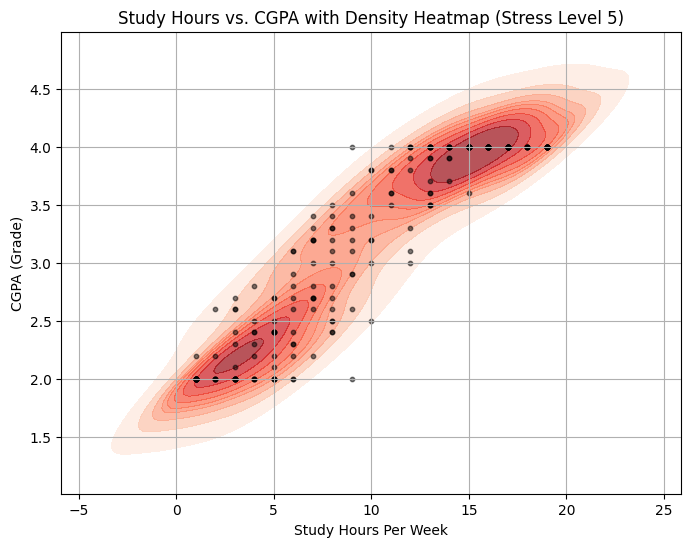

In [15]:
# กรองเฉพาะนักศึกษาที่มี stress level สูงสุด (5)
df_stress_5 = data[data['StudyStressLevel'] == 5]

plt.figure(figsize=(8, 6))
sns.kdeplot(x=df_stress_5['StudyHoursPerWeek'], y=df_stress_5['CGPA'], cmap='Reds', fill=True, thresh=0.05, alpha=0.7)

plt.scatter(df_stress_5['StudyHoursPerWeek'], df_stress_5['CGPA'], color='black', alpha=0.5, s=10)

plt.xlabel("Study Hours Per Week")
plt.ylabel("CGPA (Grade)")
plt.title("Study Hours vs. CGPA with Density Heatmap (Stress Level 5)")
plt.grid(True)

# แสดงผล
plt.show()

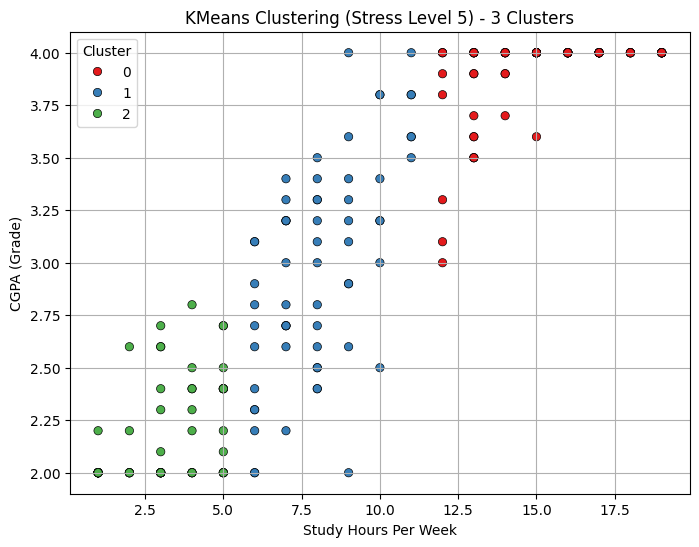

In [16]:
# KMeans k=3 — แบ่งนักศึกษากลุ่ม stress สูงเป็น 3 กลุ่มตาม CGPA และชั่วโมงเรียน
# กรองเฉพาะนักศึกษาที่มี stress level สูงสุด (5)
df_stress_5 = data[data['StudyStressLevel'] == 5][['StudyHoursPerWeek', 'CGPA']]

# KMeans clustering แบ่งเป็น 3 กลุ่ม
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_stress_5['Cluster'] = kmeans.fit_predict(df_stress_5)

# แสดงผล clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_stress_5['StudyHoursPerWeek'], y=df_stress_5['CGPA'],
                hue=df_stress_5['Cluster'], palette='Set1', edgecolor='black')

plt.xlabel("Study Hours Per Week")
plt.ylabel("CGPA (Grade)")
plt.title("KMeans Clustering (Stress Level 5) - 3 Clusters")
plt.legend(title="Cluster")
plt.grid(True)

# แสดงผล
plt.show()



Summary Statistics:
                Age         CGPA   Depression      Anxiety  PanicAttack  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     21.402000     3.122600     0.483000     0.474000     0.458000   
std       2.373611     0.811399     0.499961     0.499573     0.498482   
min      18.000000     2.000000     0.000000     0.000000     0.000000   
25%      19.000000     2.200000     0.000000     0.000000     0.000000   
50%      21.000000     3.200000     0.000000     0.000000     0.000000   
75%      24.000000     4.000000     1.000000     1.000000     1.000000   
max      25.000000     4.000000     1.000000     1.000000     1.000000   

       SpecialistTreatment  SymptomFrequency_Last7Days  \
count          1000.000000                   1000.0000   
mean              0.067000                      3.4980   
std               0.250147                      2.3081   
min               0.000000                      0.0000   
25%               0.0

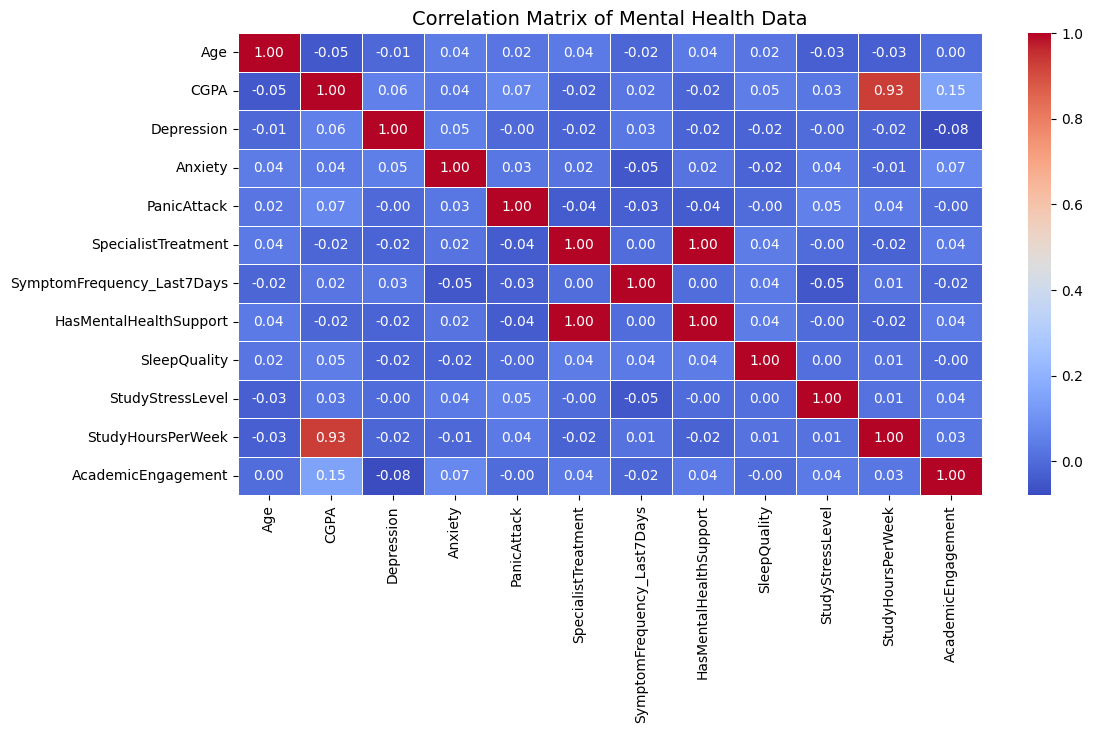

In [17]:
summary_statistics = data.describe()
print("\nSummary Statistics:\n", summary_statistics)

plt.figure(figsize=(12, 6))
plt.title("Correlation Matrix of Mental Health Data", fontsize=14)
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

## 🔍 Insight
ตัวแปรที่มี correlation สูงที่สุดกับ Anxiety คือ Depression และ PanicAttack ซึ่งมักเกิดร่วมกัน ส่วน CGPA และ SleepQuality มีความสัมพันธ์น้อยมากกับ stress

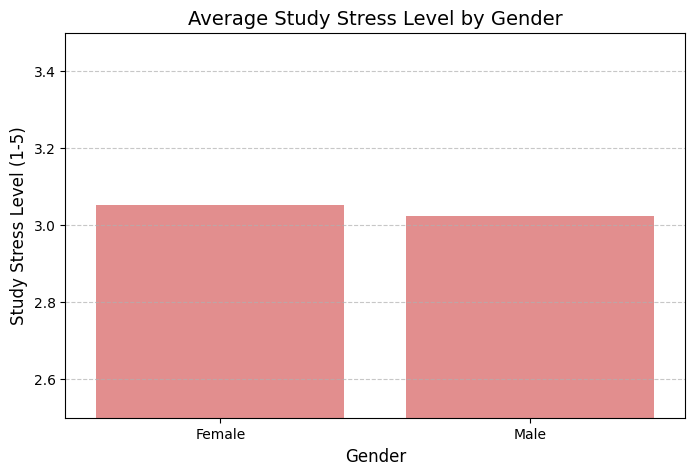

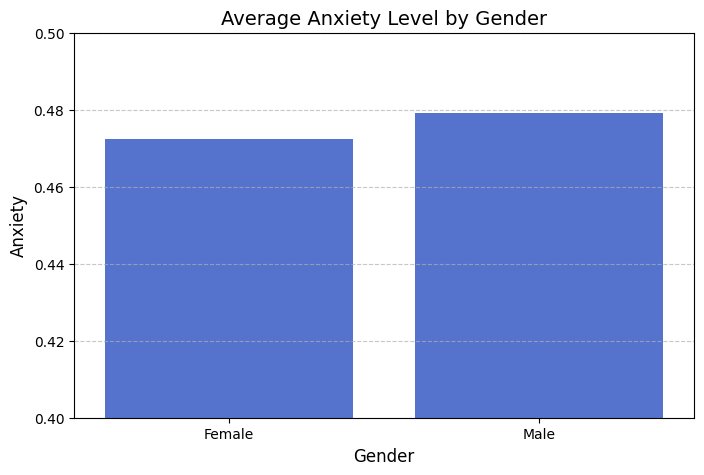

In [18]:
gender_stress_anxiety = data.groupby("Gender")[["StudyStressLevel", "Anxiety"]].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=gender_stress_anxiety.index, y=gender_stress_anxiety["StudyStressLevel"], color="lightcoral")
plt.title("Average Study Stress Level by Gender", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Study Stress Level (1-5)", fontsize=12)
plt.ylim(2.5, 3.5)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=gender_stress_anxiety.index, y=gender_stress_anxiety["Anxiety"], color="royalblue")
plt.title("Average Anxiety Level by Gender", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Anxiety", fontsize=12)
plt.ylim(0.4, 0.5)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

C:\Users\atasd\AppData\Local\Temp\ipykernel_23776\1018721526.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=correlation_matrix.index, x=correlation_matrix["Study Stress Level"], ax=axes[0], palette="Reds_r")
C:\Users\atasd\AppData\Local\Temp\ipykernel_23776\1018721526.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=correlation_matrix.index, x=correlation_matrix["Anxiety"], ax=axes[1], palette="Blues_r")


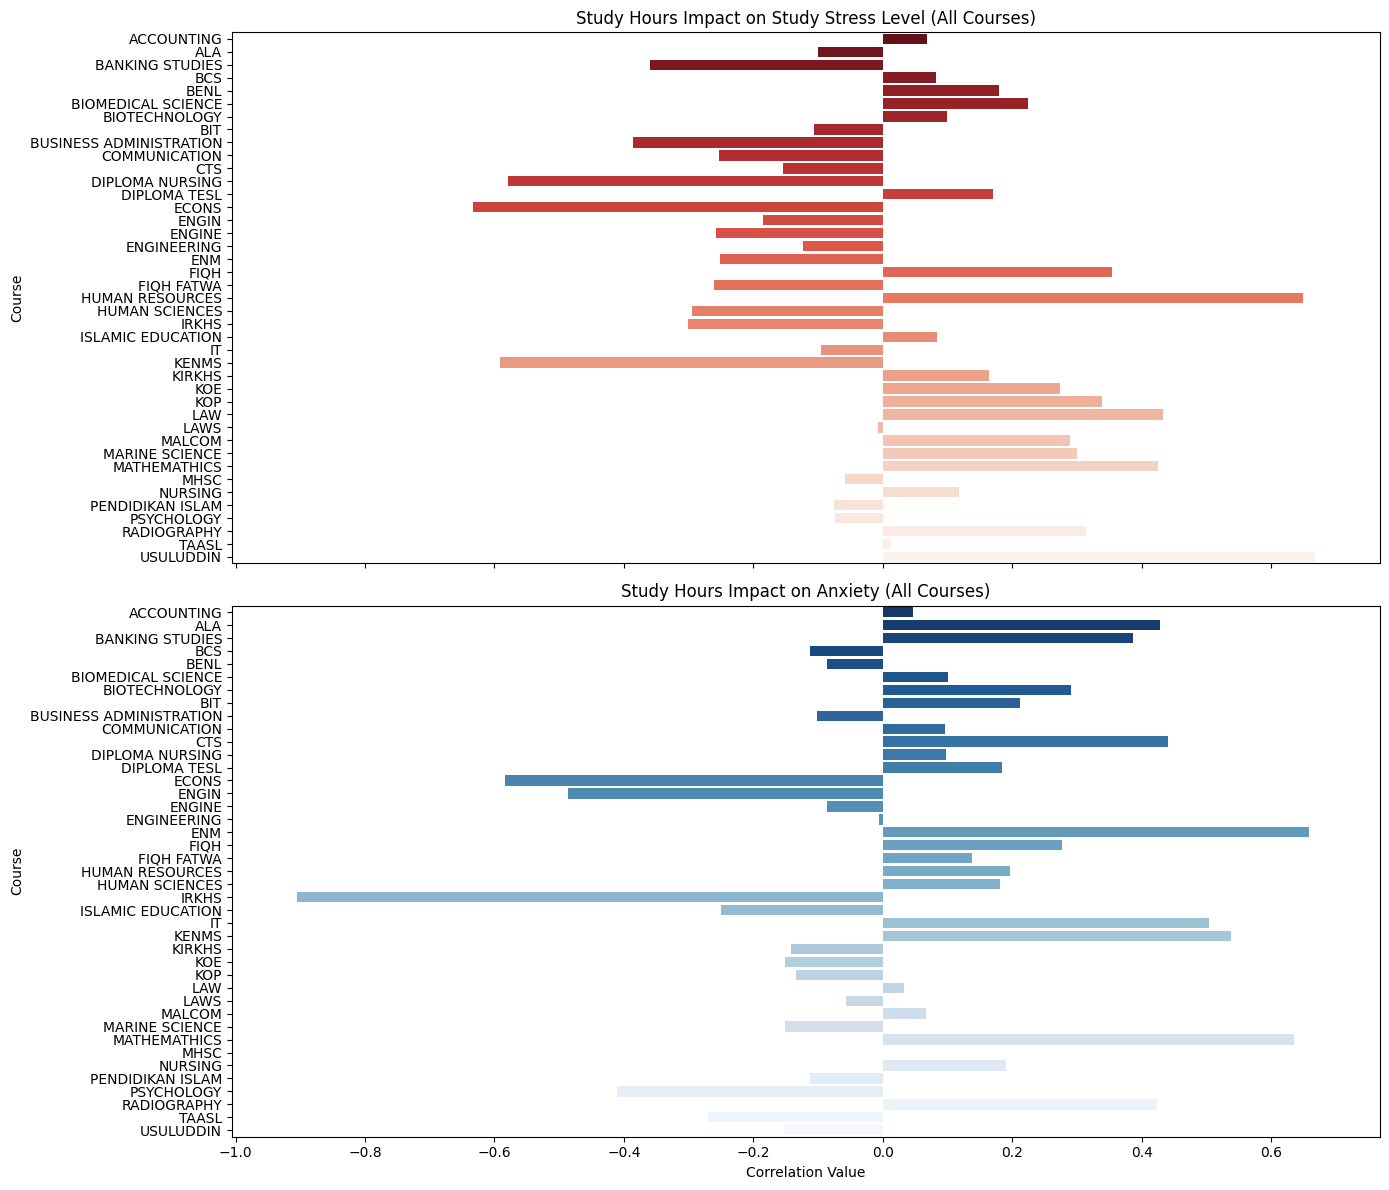

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

course_correlation = df.groupby("Course")[["StudyHoursPerWeek", "StudyStressLevel", "Anxiety"]].corr().reset_index()

course_stress_corr = course_correlation[(course_correlation["level_1"] == "StudyStressLevel") & (course_correlation["StudyHoursPerWeek"] != 1.0)]
course_anxiety_corr = course_correlation[(course_correlation["level_1"] == "Anxiety") & (course_correlation["StudyHoursPerWeek"] != 1.0)]

# สร้าง DataFrame สำหรับ Heatmap
correlation_matrix = pd.DataFrame({
    "Study Stress Level": course_stress_corr.set_index("Course")["StudyHoursPerWeek"],
    "Anxiety": course_anxiety_corr.set_index("Course")["StudyHoursPerWeek"]
}).dropna()

# ปรับแกน X ให้ scale เท่ากันทุกกราฟ
x_min = min(correlation_matrix["Study Stress Level"].min(), correlation_matrix["Anxiety"].min()) - 0.1
x_max = max(correlation_matrix["Study Stress Level"].max(), correlation_matrix["Anxiety"].max()) + 0.1

# สร้างกราฟแสดงทุกหลักสูตรที่มีค่าความสัมพันธ์ระหว่าง Study Hours กับ Study Stress Level และ Anxiety
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# กราฟ 1: Study Hours vs Stress Level
sns.barplot(y=correlation_matrix.index, x=correlation_matrix["Study Stress Level"], ax=axes[0], palette="Reds_r")
axes[0].set_title("Study Hours Impact on Study Stress Level (All Courses)")
axes[0].set_xlabel("Correlation Value")
axes[0].set_ylabel("Course")
axes[0].set_xlim(x_min, x_max)  # ปรับ scale แกน X

# กราฟ 2: Study Hours vs Anxiety
sns.barplot(y=correlation_matrix.index, x=correlation_matrix["Anxiety"], ax=axes[1], palette="Blues_r")
axes[1].set_title("Study Hours Impact on Anxiety (All Courses)")
axes[1].set_xlabel("Correlation Value")
axes[1].set_ylabel("Course")
axes[1].set_xlim(x_min, x_max)  # ปรับ scale แกน X

# จัด layout
plt.tight_layout()
plt.show()


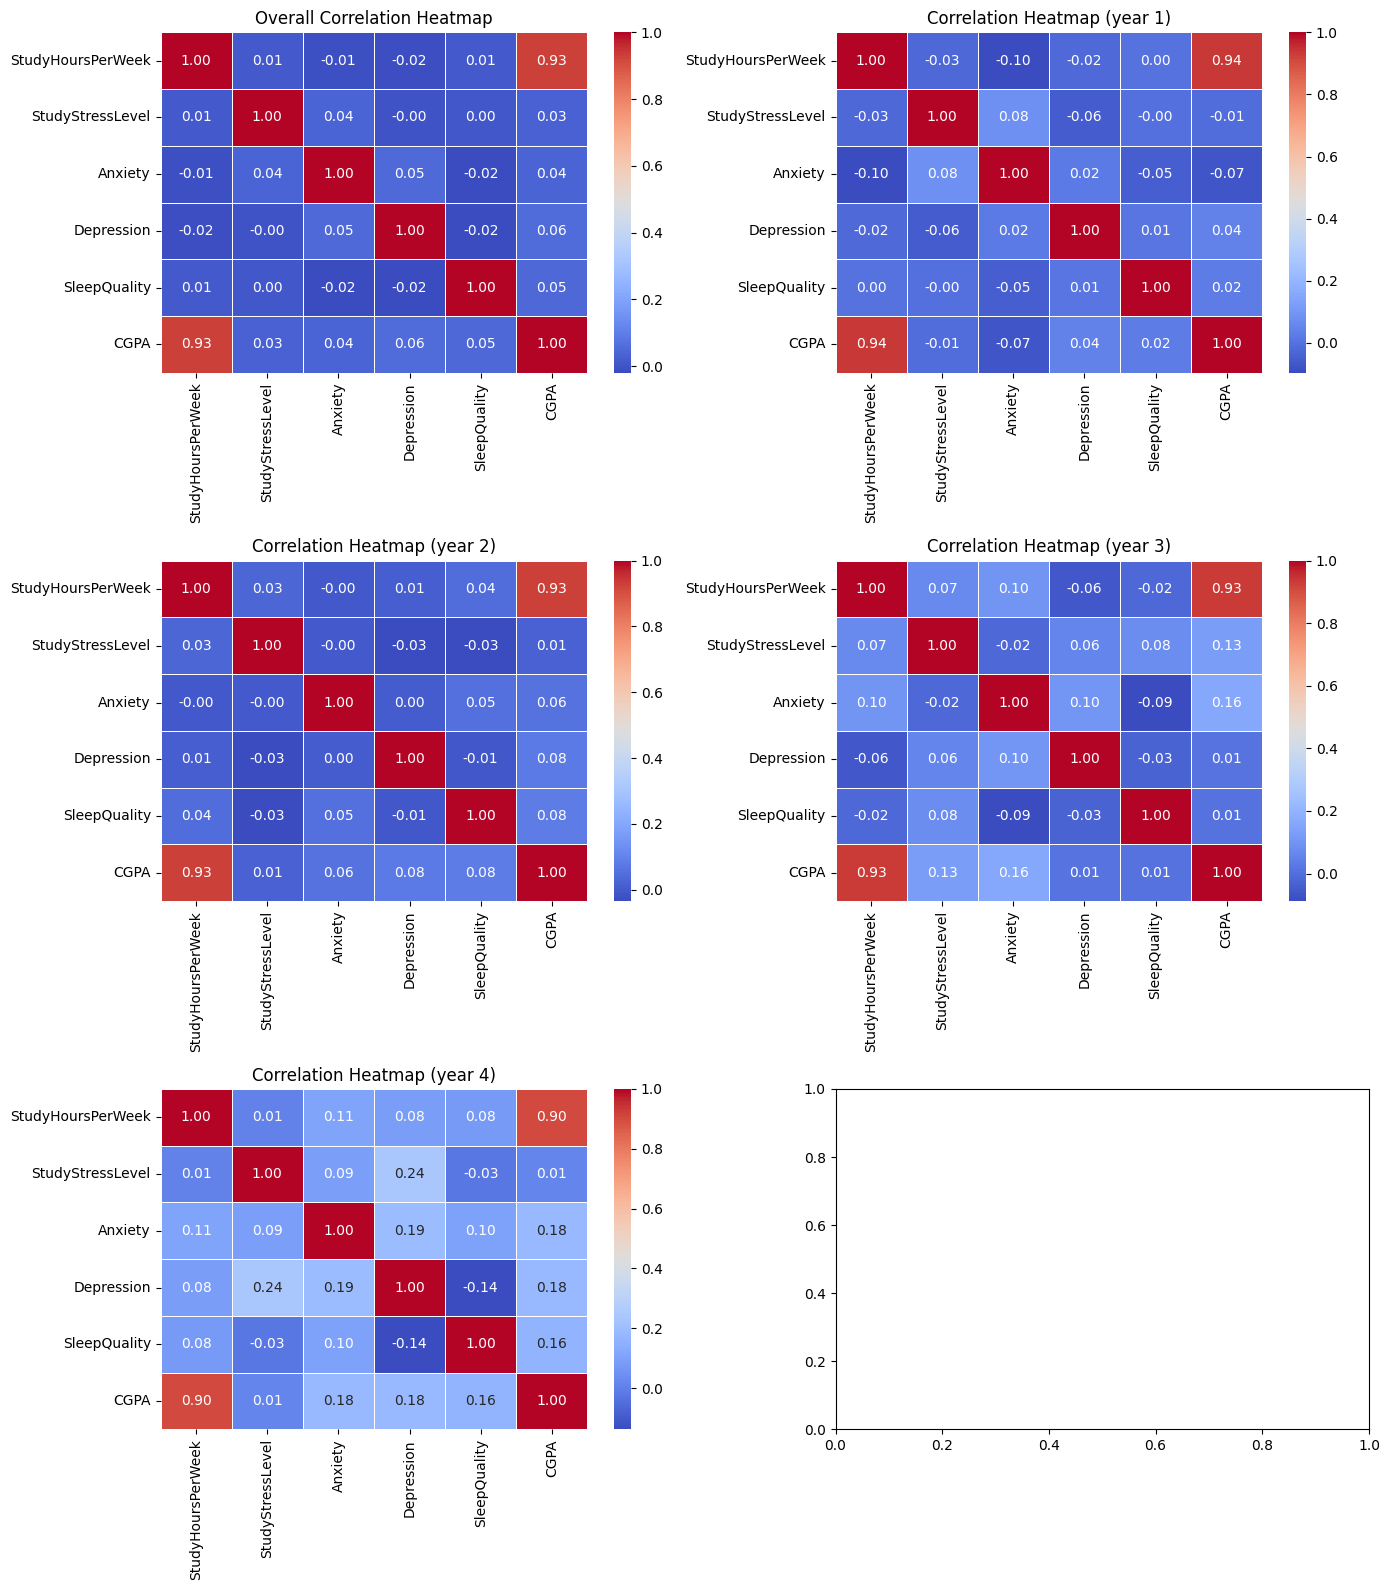

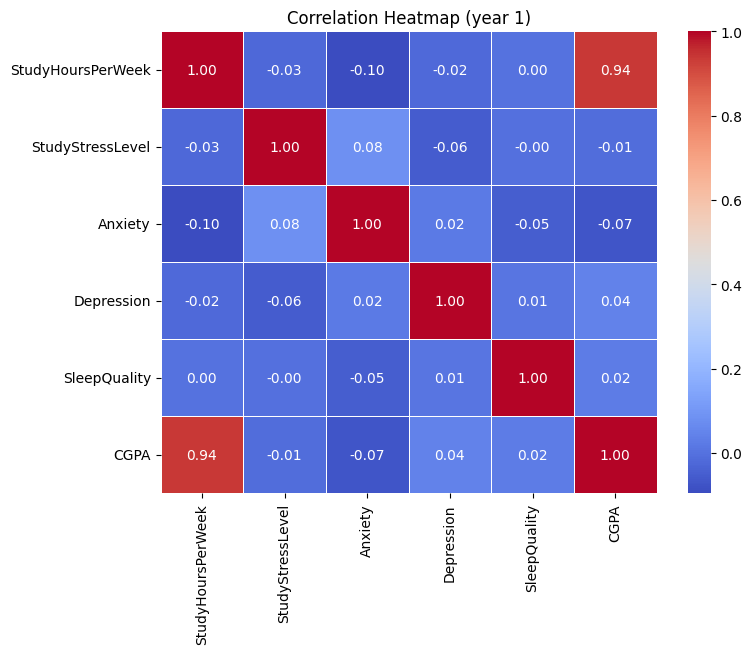

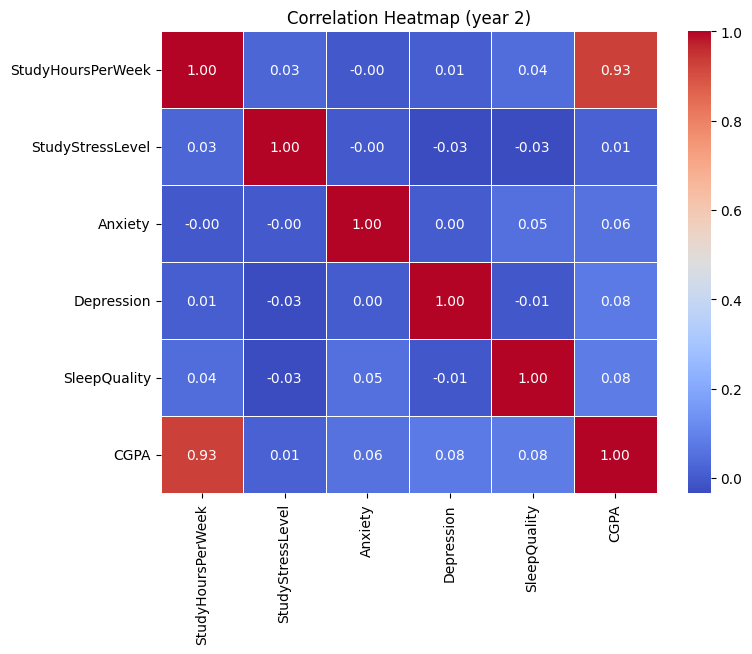

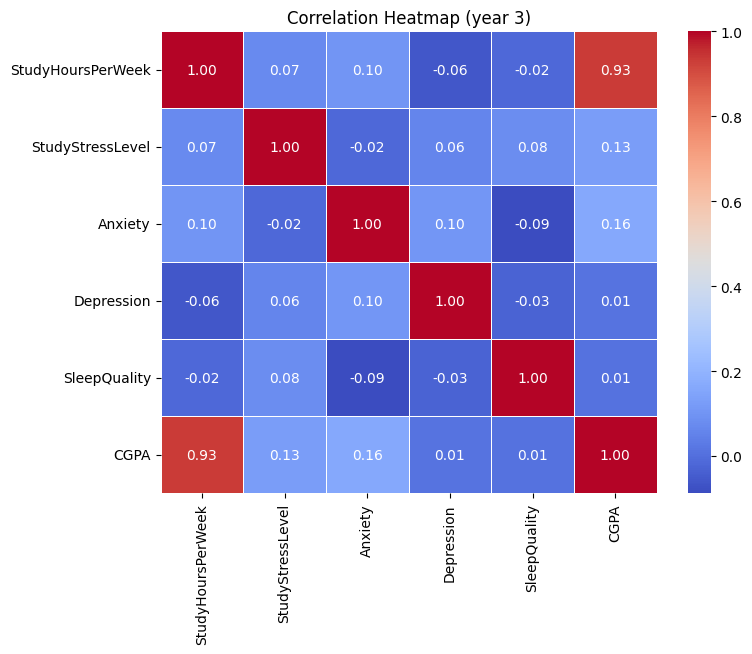

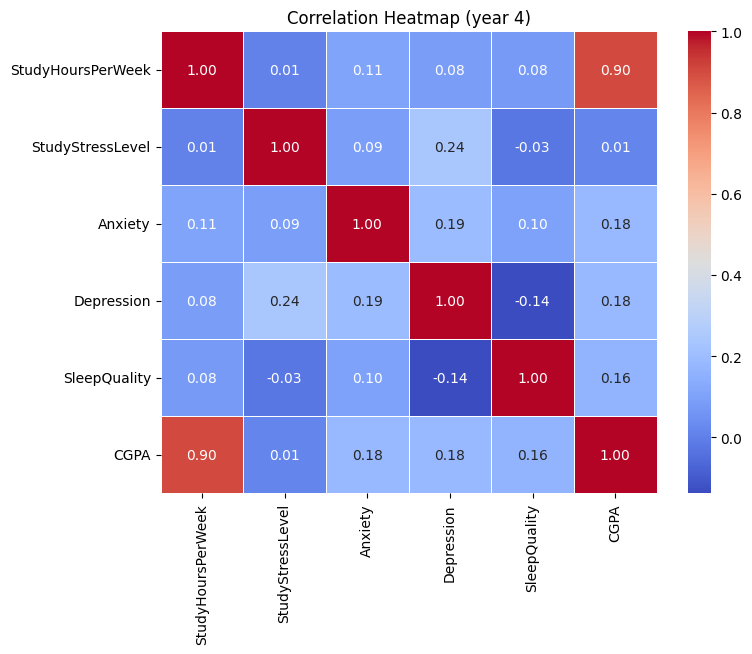

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



selected_columns = ["StudyHoursPerWeek", "StudyStressLevel", "Anxiety", "Depression", "SleepQuality", "CGPA"]

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# Heatmap ภาพรวม
correlation_matrix = df[selected_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axes[0, 0])
axes[0, 0].set_title("Overall Correlation Heatmap")

# Heatmap แยกตามชั้นปี
years = ["year 1", "year 2", "year 3", "year 4"]

for i, year in enumerate(years):
    row, col = divmod(i + 1, 2)  # เริ่ม plot จากตำแหน่งถัดไป
    correlation_matrix_year = df[df["YearOfStudy"] == year][selected_columns].corr()

    sns.heatmap(correlation_matrix_year, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axes[row, col])
    axes[row, col].set_title(f"Correlation Heatmap ({year})")

# จัด layout
plt.tight_layout()
plt.show()

# แสดงผล
for year in years:
    plt.figure(figsize=(8, 6))
    correlation_matrix_year = df[df["YearOfStudy"] == year][selected_columns].corr()
    sns.heatmap(correlation_matrix_year, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(f"Correlation Heatmap ({year})")
    plt.show()


C:\Users\atasd\AppData\Local\Temp\ipykernel_23776\1974191741.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=correlation_matrix_sorted_stress.index, x=correlation_matrix_sorted_stress["Study Stress Level"], palette=colors_stress)


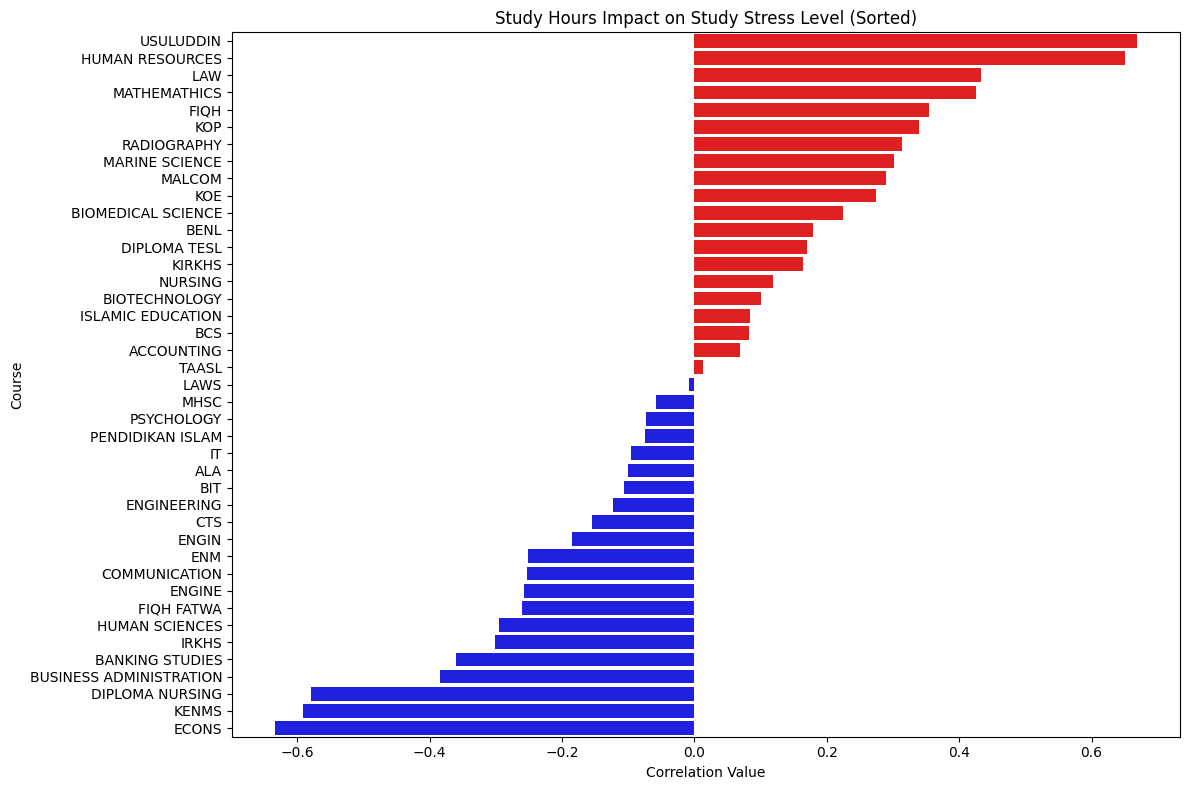

C:\Users\atasd\AppData\Local\Temp\ipykernel_23776\1974191741.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=correlation_matrix_sorted_anxiety.index, x=correlation_matrix_sorted_anxiety["Anxiety"], palette=colors_anxiety)


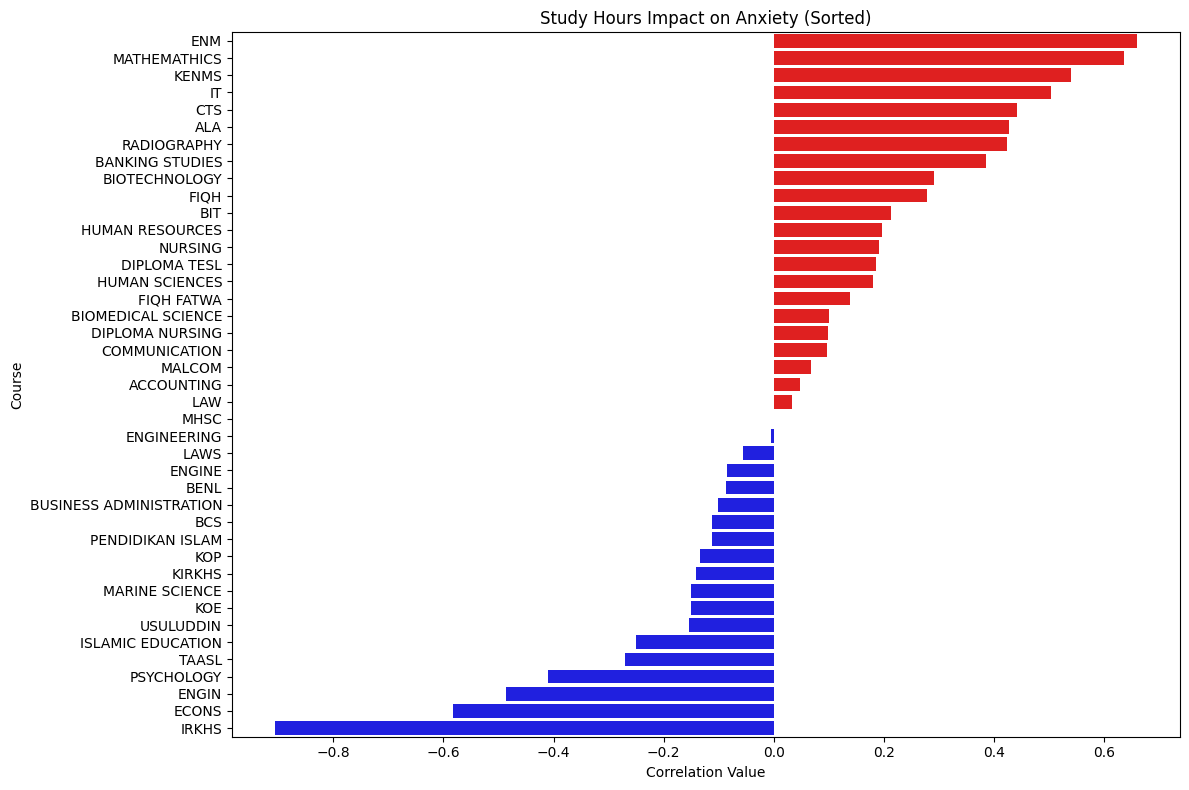

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "mentalhealth_dataset_clean.csv"
df = pd.read_csv(file_path)

course_correlation = df.groupby("Course")[["StudyHoursPerWeek", "StudyStressLevel", "Anxiety"]].corr().reset_index()

course_stress_corr = course_correlation[(course_correlation["level_1"] == "StudyStressLevel") & (course_correlation["StudyHoursPerWeek"] != 1.0)]
course_anxiety_corr = course_correlation[(course_correlation["level_1"] == "Anxiety") & (course_correlation["StudyHoursPerWeek"] != 1.0)]

# สร้าง DataFrame สำหรับ Heatmap
correlation_matrix = pd.DataFrame({
    "Study Stress Level": course_stress_corr.set_index("Course")["StudyHoursPerWeek"],
    "Anxiety": course_anxiety_corr.set_index("Course")["StudyHoursPerWeek"]
}).dropna()

# เรียง correlation มากไปน้อย
correlation_matrix_sorted_stress = correlation_matrix.sort_values(by="Study Stress Level", ascending=False)
correlation_matrix_sorted_anxiety = correlation_matrix.sort_values(by="Anxiety", ascending=False)

# สีส้ม = สัมพันธ์บวก, สีฟ้า = สัมพันธ์ต่ำ
colors_stress = ["red" if val > 0 else "blue" for val in correlation_matrix_sorted_stress["Study Stress Level"]]
colors_anxiety = ["red" if val > 0 else "blue" for val in correlation_matrix_sorted_anxiety["Anxiety"]]

# กราฟ Stress Level
plt.figure(figsize=(12, 8))
sns.barplot(y=correlation_matrix_sorted_stress.index, x=correlation_matrix_sorted_stress["Study Stress Level"], palette=colors_stress)
plt.title("Study Hours Impact on Study Stress Level (Sorted)")
plt.xlabel("Correlation Value")
plt.ylabel("Course")
plt.tight_layout()



# แสดงผล
plt.show()

# กราฟ Anxiety
plt.figure(figsize=(12, 8))
sns.barplot(y=correlation_matrix_sorted_anxiety.index, x=correlation_matrix_sorted_anxiety["Anxiety"], palette=colors_anxiety)
plt.title("Study Hours Impact on Anxiety (Sorted)")
plt.xlabel("Correlation Value")
plt.ylabel("Course")
plt.tight_layout()



# แสดงผล
plt.show()




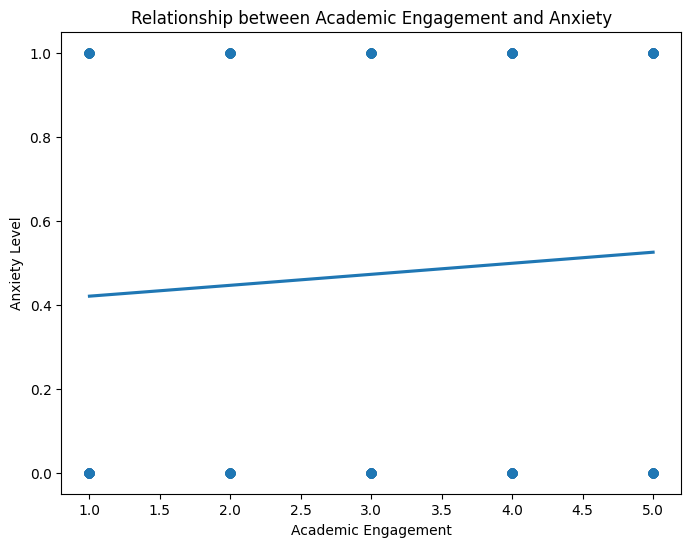

In [22]:
plt.figure(figsize=(8, 6))
sns.regplot(x=df["AcademicEngagement"], y=df["Anxiety"], logistic=True, ci=None)

plt.xlabel("Academic Engagement")
plt.ylabel("Anxiety Level")
plt.title("Relationship between Academic Engagement and Anxiety")

plt.show()

Pearson Correlation: 0.075


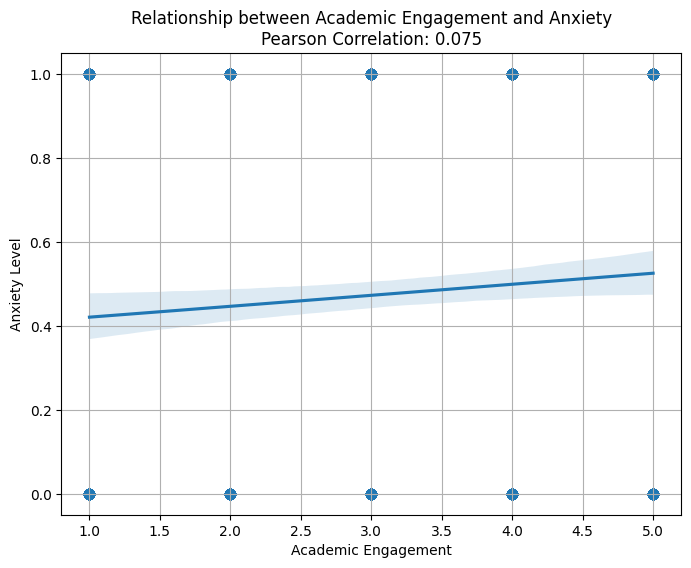

In [23]:
correlation_value = np.corrcoef(df["AcademicEngagement"], df["Anxiety"])[0, 1]

plt.figure(figsize=(8, 6))
sns.regplot(x=df["AcademicEngagement"], y=df["Anxiety"], logistic=True, scatter_kws={"s": 50, "alpha": 0.7})

plt.xlabel("Academic Engagement")
plt.ylabel("Anxiety Level")
plt.title(f"Relationship between Academic Engagement and Anxiety\nPearson Correlation: {correlation_value:.3f}")
plt.grid(True)

correlation_value = np.corrcoef(df["AcademicEngagement"], df["Anxiety"])[0, 1]
print(f"Pearson Correlation: {correlation_value:.3f}")

plt.show()

## 🔍 Insight
Academic Engagement มี Pearson Correlation ต่ำกับ Anxiety แสดงว่าการมีส่วนร่วมในการเรียนไม่ได้เพิ่มหรือลด anxiety อย่างมีนัยสำคัญ

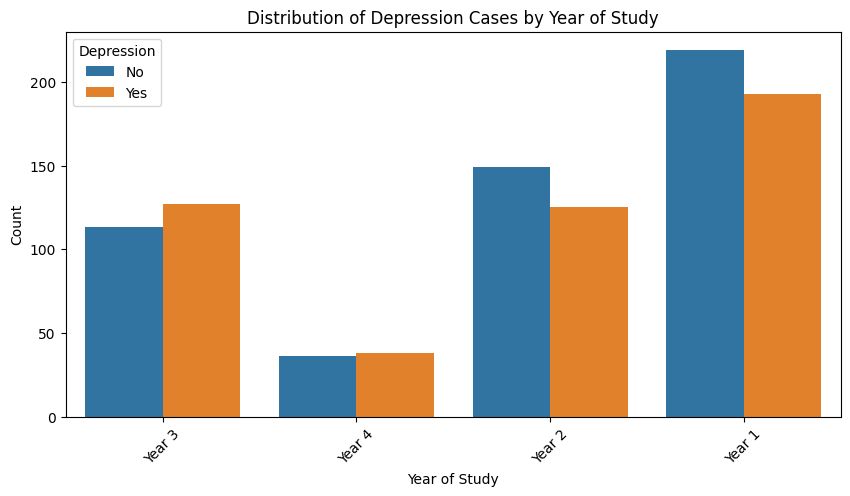

In [24]:
df['YearOfStudy'] = df['YearOfStudy'].str.strip().str.title()

plt.figure(figsize=(10, 5))
sns.countplot(x="YearOfStudy", hue="Depression", data=df)
plt.title("Distribution of Depression Cases by Year of Study")
plt.xlabel("Year of Study")
plt.ylabel("Count")
plt.legend(title="Depression", labels=["No", "Yes"])
plt.xticks(rotation=45)
plt.show()


## 🔍 Insight
นักศึกษาปี 1 มีจำนวน Depression cases สูงที่สุด อาจเพราะเพิ่งปรับตัวกับชีวิตมหาวิทยาลัย

# 📌 Key Findings

1. **นักศึกษาส่วนใหญ่มีปัญหาสุขภาพจิต** — Depression, Anxiety หรือ PanicAttack อย่างน้อย 1 อย่าง พบได้ทั่วไปในกลุ่มตัวอย่าง
2. **Stress สูงไม่ได้แปลว่าเรียนหนักกว่า** — นักศึกษาที่มี StudyStressLevel ระดับ 5 มี CGPA และชั่วโมงเรียนกระจายไม่ต่างจากกลุ่มอื่น
3. **Depression, Anxiety และ PanicAttack มักเกิดร่วมกัน** — มี correlation สูงระหว่างกัน แต่สัมพันธ์น้อยกับ CGPA
4. **Academic Engagement ไม่สัมพันธ์กับ Anxiety** — การมีส่วนร่วมในการเรียนไม่ได้เพิ่มหรือลด anxiety อย่างมีนัยสำคัญ
5. **นักศึกษาปี 1 มี Depression สูงที่สุด** — อาจสะท้อนความยากในการปรับตัวช่วงแรกของมหาวิทยาลัย